In [ ]:
import os
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, gaussian_kde, linregress, ttest_ind, sem, zscore
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import norm
from scipy.stats import percentileofscore
from sklearn.utils.validation import check_random_state
from math import factorial
from more_itertools import distinct_permutations
import statsmodels.api as sm

import matplotlib.pyplot as plt

import pandas as pd
from sklearn.model_selection import KFold, train_test_split, StratifiedKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy import stats

import numpy as np
from scipy.stats import linregress
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold, ParameterGrid, train_test_split
from tqdm.notebook import tqdm

import warnings
import random
#from torch.utils.data import SubsetRandomSampler
from sklearn.utils import resample

from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.diagnostic import linear_harvey_collier
from scipy.stats import chi2
from sklearn.model_selection import train_test_split
from colorama import Fore, Style, init
from sklearn.metrics import roc_auc_score
from collections import Counter

from statsmodels.stats.diagnostic import linear_harvey_collier
from scipy.stats import chi2
from sklearn.model_selection import train_test_split
from colorama import Fore, Style, init
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")



In [ ]:
from scipy.stats import chi2

def summarize_feature(df, feature, df_out, stat_cols=(10, 50), df_offset=2):

    d = df[df["Feature"] == feature]
    if d.empty:
        return df_out  

    for k in stat_cols:
        col = f"hl_statistic_{k}"
        if col in d.columns:
            df_chi = k - df_offset
            combined_p = 1 - chi2.cdf(d[col].mean(), df_chi)
            df_out.loc[feature, f"hl_pvalue_combined_{k}"] = combined_p

    # --- RR summary ---
    if "RR" in d.columns:
        or_mean = d["RR"].mean()
        or_std = d["RR"].std(ddof=1)
        df_out.loc[feature, "RR"] = or_mean
        df_out.loc[feature, "2.5%"] = or_mean - or_std
        df_out.loc[feature, "97.5%"] = or_mean + or_std

    # --- min/max de los IC originales (tal como lo estabas haciendo) ---
    if "2.5%" in d.columns:
        df_out.loc[feature, "minRR"] = d["2.5%"].min()
    if "97.5%" in d.columns:
        df_out.loc[feature, "maxRR"] = d["97.5%"].max()

    return df_out


features = ["Mono", "One", "Two", "Three", "Total"] 




def hosmer_lemeshow(y_true, y_prob, g):
    hl_df = pd.DataFrame({
        "observed": y_true,
        "predicted_probability": y_prob
    }).dropna()


    hl_df["group"] = pd.qcut(hl_df["predicted_probability"], g, duplicates="drop")

    hl_table = hl_df.groupby("group").apply(
        lambda x: pd.Series({
            "observed": x["observed"].sum(),
            "expected": x["predicted_probability"].sum(),
            "total": len(x)
        })
    )

    hl_table["observed_neg"] = hl_table["total"] - hl_table["observed"]
    hl_table["expected_neg"] = hl_table["total"] - hl_table["expected"]


    hl_statistic = (
        ((hl_table["observed"] - hl_table["expected"])**2) / hl_table["expected"] +
        ((hl_table["observed_neg"] - hl_table["expected_neg"])**2) / hl_table["expected_neg"]
    ).sum()


    dof = hl_table.shape[0] - 2
    p_value = 1 - chi2.cdf(hl_statistic, dof)

    return hl_statistic, p_value



def summarize_feature_by_covar(df, covar, feature, df_out, stat_cols=(10, 50), df_offset=2):
    d = df[(df["Covar"] == covar) & (df["Feature"] == feature)]
    if d.empty:
        return df_out

    idx = (covar, feature)

    for k in stat_cols:
        col = f"hl_statistic_{k}"
        if col in d.columns:
            df_chi = k - df_offset
            df_out.loc[idx, f"hl_pvalue_combined_{k}"] = 1 - chi2.cdf(d[col].mean(), df_chi)

    or_mean = d["RR"].mean()
    or_std  = d["RR"].std(ddof=1)
    df_out.loc[idx, "RR"] = or_mean
    df_out.loc[idx, "2.5%"] = or_mean - or_std
    df_out.loc[idx, "97.5%"] = or_mean + or_std

    df_out.loc[idx, "minRR"] = d["2.5%"].min()
    df_out.loc[idx, "maxRR"] = d["97.5%"].max()

    df_out.loc[idx, "n_iter"] = d.shape[0]

    return df_out


## Load data

In [ ]:
import time

t0 = time.perf_counter()


In [ ]:
data = pd.read_csv('DataShare/BBAG-long.csv')

In [ ]:
vars_ = ['Mono', 'One',	'Two',	'Three', 'Total']


# Relative Risk

## Without co-vars

### Main model

In [ ]:
import pandas as pd
import numpy as np

import statsmodels.api as sm

from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


results_merge_df_all = data.copy()
results_merge_df_all = results_merge_df_all.loc[:, ~results_merge_df_all.columns.duplicated()]


def summarize_from_models(rr_values, ci_low_values, ci_high_values, z_values):
    rr_values = np.array(rr_values)
    ci_low_values = np.array(ci_low_values)
    ci_high_values = np.array(ci_high_values)
    z_values = np.array(z_values)

    rr_mean = np.mean(rr_values)
    ci_low_mean = np.mean(ci_low_values)
    ci_high_mean = np.mean(ci_high_values)
    z_mean = np.mean(z_values)

    return ci_low_mean, ci_high_mean, rr_mean, z_mean


def p_value_from_effect_ci(effect_mean, ci_low, ci_high):
    if effect_mean <= 0 or ci_low <= 0 or ci_high <= 0:
        return np.nan, np.nan

    se_log_effect = (np.log(ci_high) - np.log(ci_low)) / (2 * 1.96)

    if se_log_effect == 0:
        return np.nan, np.nan

    z_combined = np.log(effect_mean) / se_log_effect
    p_combined = 2 * (1 - norm.cdf(abs(z_combined)))

    return z_combined, p_combined


n_iterations = 1000

df_directions_odd = pd.DataFrame()

for i in vars_:

    print(i)

    c_results_merge_df_all = results_merge_df_all.copy()

    c_results_merge_df_all.dropna(
        subset=[i, "delta_time", "GAP_bin", "country", "GAP_corrected"],
        inplace=True
    )

    c_results_merge_df_all.reset_index(drop=True, inplace=True)

    X_resid = sm.add_constant(c_results_merge_df_all[["delta_time"]])

    resid_model = sm.OLS(
        c_results_merge_df_all["GAP_corrected"],
        X_resid
    ).fit()

    c_results_merge_df_all["GAP_corrected"] = resid_model.resid

    c_results_merge_df_all["GAP_bin"] = np.where(
        c_results_merge_df_all["GAP_corrected"] > 0,
        1,
        0
    )

    y_ols = c_results_merge_df_all["GAP_bin"]
    X_ols = c_results_merge_df_all[[i]].copy()

    rr_values = []
    ci_low_values = []
    ci_high_values = []
    z_values = []


    for iteration in range(n_iterations):

        try:
            X_train, X_test, y_train, y_test = train_test_split(
                X_ols,
                y_ols,
                test_size=0.2,
                random_state=iteration
            )

            scaler = MinMaxScaler((0.05, 0.95))

            X_train_scaled = scaler.fit_transform(X_train)
            X_train_scaled = pd.DataFrame(
                X_train_scaled,
                columns=X_train.columns,
                index=X_train.index
            )

            X_test_scaled = scaler.transform(X_test)
            X_test_scaled = pd.DataFrame(
                X_test_scaled,
                columns=X_test.columns,
                index=X_test.index
            )

            X_train_scaled["intercept"] = 1
            X_test_scaled["intercept"] = 1

            model = sm.GLM(
                y_train,
                X_train_scaled,
                family=sm.families.Binomial(
                    link=sm.families.links.log()
                )
            ).fit(disp=0)

            params = model.params

            conf = np.exp(model.conf_int())
            conf["RR"] = np.exp(params)
            conf["z"] = model.tvalues
            conf["P>|z|"] = model.pvalues
            conf.columns = ["2.5%", "97.5%", "RR", "z", "P>|z|"]

            rr_values.append(conf.loc[i, "RR"])
            ci_low_values.append(conf.loc[i, "2.5%"])
            ci_high_values.append(conf.loc[i, "97.5%"])
            z_values.append(conf.loc[i, "z"])

        except Exception as e:
            print(f"Iteration {iteration} failed for {i}: {e}")


    if len(rr_values) > 1:

        ci_low, ci_high, rr_mean, z_mean_original = summarize_from_models(
            rr_values=rr_values,
            ci_low_values=ci_low_values,
            ci_high_values=ci_high_values,
            z_values=z_values
        )

        z_combined, p_combined = p_value_from_effect_ci(
            effect_mean=rr_mean,
            ci_low=ci_low,
            ci_high=ci_high
        )

    else:

        ci_low = np.nan
        ci_high = np.nan
        rr_mean = np.nan
        z_mean_original = np.nan
        z_combined = np.nan
        p_combined = np.nan

    df_temp = pd.DataFrame({
        "2.5%": [ci_low],
        "97.5%": [ci_high],
        "RR": [rr_mean],
        "z": [z_combined],
        "P>|z|": [f"{p_combined:.2e}" if not np.isnan(p_combined) else np.nan],       
        "z_mean_original": [z_mean_original],
        "Feature": [i],
        "n_iterations_ok": [len(rr_values)]
    })

    df_directions_odd = pd.concat(
        [df_directions_odd, df_temp],
        ignore_index=True
    )


df_directions_odd = df_directions_odd.reset_index(drop=True)

df_directions_odd.to_excel('Results/long/long_RR_-with-slovakia-final.xlsx')
df_directions_odd

In [ ]:
plt.figure(figsize=(7.5, 7.5))
count = 1




covar_cross = df_directions_odd.copy()

covar_cross = covar_cross.set_index("Feature")
cols_to_round = ["2.5%", "97.5%", "RR", "z"]
covar_cross[cols_to_round] = covar_cross[cols_to_round].round(2)
covar_cross["CI 90"] = covar_cross.apply(
    lambda row: f"[{row['2.5%']}, {row['97.5%']}]", 
    axis=1
)

covar_cross["RR_"] = covar_cross["RR"]
covar_cross["z_"] = covar_cross["z"]
covar_cross["P>|z|_"] = covar_cross["P>|z|"]
df_plot = covar_cross.copy()
df_plot.reset_index(inplace=True)
plt.subplot(5, 3, count)
plt.errorbar(
    df_plot["RR"],
    df_plot["Feature"],
    xerr=[
        df_plot["RR"] - df_plot["2.5%"],
        df_plot["97.5%"] - df_plot["RR"]
    ],
    fmt="none",
    c="k",
    capsize=5
)
plt.scatter(
    df_plot["RR"],
    df_plot["Feature"],
    color="red",
    zorder=10
)
plt.axvline(
    x=1,
    color="red",
    linestyle="--",
    linewidth=2
)
plt.xlim([0, 3.0])
plt.title("RR [95% CI]", fontsize=9)
plt.xlabel("Odds Ratio")
plt.ylabel("Feature")
count += 1

plt.tight_layout()

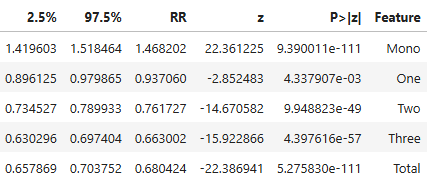

### Stability 1000-iteration

In [ ]:


count = 0

results_dict = {}
for i in vars_:
    results_dict[i + "_y"] = pd.Series(dtype=float)
    results_dict[i + "_ypred"] = pd.Series(dtype=float)

results_merge_df_all = data.copy()


df_directions_odd = pd.DataFrame()

n_boosts = 1000  #For performance reasons, the number of iterations was set to 10; however, 1,000 iterations were used for the results reported in the manuscript.”
test_size = 500 / results_merge_df_all.shape[0]

for boosts in range(n_boosts):
    for i in vars_:

        X_resid = sm.add_constant(results_merge_df_all[["delta_time"]])
    
        resid_model = sm.OLS(
            results_merge_df_all["GAP_corrected"],
            X_resid
        ).fit()
    
        results_merge_df_all["GAP_corrected"] = resid_model.resid
    
        results_merge_df_all["GAP_bin"] = np.where(
            results_merge_df_all["GAP_corrected"] > 0,
            1,
            0
        )

        y_ols = results_merge_df_all["GAP_bin"]
        X_ols = results_merge_df_all[[i] + ['delta_time']]

        X_train, X_test, y_train, y_test = train_test_split(
            X_ols, y_ols,
            test_size=test_size,
            stratify=results_merge_df_all["GAP_bin"],
            random_state=boosts
        )

        scaler = MinMaxScaler((0.05, 0.95))

        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )
        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
        )

        X_train_scaled["intercept"] = 1
        X_test_scaled["intercept"] = 1


        model = sm.GLM(y_train, X_train_scaled, family=sm.families.Binomial(link=sm.families.links.log())).fit(disp = 0)


        y_test_pred = model.predict(X_test_scaled)

        results_dict[i + "_y"] = pd.concat([results_dict[i + "_y"], y_test], axis=0)
        results_dict[i + "_ypred"] = pd.concat([results_dict[i + "_ypred"], y_test_pred], axis=0)

        params = model.params
        conf = np.exp(model.conf_int())
        conf["RR"] = np.exp(params)
        conf["z"] = model.tvalues
        conf["P>|z|"] = model.pvalues
        conf.columns = ["2.5%", "97.5%", "RR", "z", "P>|z|"]

        df = conf.loc[i:i].copy()
        df["Feature"] = i

        hl10_stat, hl10_p = hosmer_lemeshow(y_test, y_test_pred, g=10)
        hl50_stat, hl50_p = hosmer_lemeshow(y_test, y_test_pred, g=50)
        hl100_stat, hl100_p = hosmer_lemeshow(y_test, y_test_pred, g=100)

        df["hl_statistic_10"] = hl10_stat
        df["hl_pvalue_10"] = hl10_p

        df["hl_statistic_50"] = hl50_stat
        df["hl_pvalue_50"] = hl50_p

        df["hl_statistic_100"] = hl100_stat
        df["hl_pvalue_100"] = hl100_p

        df_directions_odd = pd.concat([df_directions_odd, df], axis=0)

    df_directions_odd = df_directions_odd.reset_index(drop=True)

df_directions_odd;


In [ ]:
df_directions_odd_f = pd.DataFrame()

for f in vars_:
    df_directions_odd_f = summarize_feature(df_directions_odd, f, df_directions_odd_f, stat_cols=(10, 50, 100))

df_directions_odd_f.to_excel('Results/long/long_RR_-with-slovakia-stability-final.xlsx')
df_directions_odd_f

## Odd ratios with macrosocials

### Main models

In [ ]:
vars_social_physical = ['gender_equal_l', 'Polution_conc_inv', 'Eq']

vars_sociopolitical = ['free_parties_l',  'inclu_suff_est', 'cred_elect_est', 'local_dem_est']

In [ ]:
import pandas as pd
import numpy as np

import statsmodels.api as sm

from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


results_merge_df_all = data.copy()
results_merge_df_all = results_merge_df_all.loc[:, ~results_merge_df_all.columns.duplicated()]



def remove_outliers_percentiles(df, cols, lower_q=0.05, upper_q=0.95):
    df_out = df.copy()

    for col in cols:
        q_low = df_out[col].quantile(lower_q)
        q_high = df_out[col].quantile(upper_q)

        df_out = df_out[
            (df_out[col] >= q_low) &
            (df_out[col] <= q_high)
        ].copy()

    return df_out


def summarize_from_models(
    effect_values,
    ci_low_values,
    ci_high_values,
    beta_values,
    se_values,
    z_values
):
    effect_values = np.array(effect_values)
    ci_low_values = np.array(ci_low_values)
    ci_high_values = np.array(ci_high_values)
    beta_values = np.array(beta_values)
    se_values = np.array(se_values)
    z_values = np.array(z_values)

    effect_mean = np.mean(effect_values)
    ci_low_mean = np.mean(ci_low_values)
    ci_high_mean = np.mean(ci_high_values)

    beta_mean = np.mean(beta_values)
    se_mean = np.mean(se_values)

    z_combined = beta_mean / se_mean
    p_combined = 2 * (1 - norm.cdf(abs(z_combined)))

    z_mean_original = np.mean(z_values)

    return (
        ci_low_mean,
        ci_high_mean,
        effect_mean,
        beta_mean,
        se_mean,
        z_combined,
        p_combined,
        z_mean_original
    )


covar_list = (
    ['total_exposomes', 'sociopolitical', 'social_physical', 'GDP',
     'number_leng_inst', 'number_stable_inst', 'distance', 'Migration']
    + vars_social_physical
    + vars_sociopolitical
)



n_iterations = 1000

df_directions_odd_all = []
df_directions_cov_odd_all = []

for covar in covar_list:

    print("Covar:", covar)

    for i in vars_:

        print("  Feature:", i)

        c_results_merge_df_all = results_merge_df_all.copy()

        c_results_merge_df_all.dropna(
            subset=[i, covar, "delta_time", "GAP_bin", "country", "GAP_corrected"],
            inplace=True
        )

        c_results_merge_df_all.reset_index(drop=True, inplace=True)


        X_resid = sm.add_constant(c_results_merge_df_all[["delta_time"]])

        resid_model = sm.OLS(
            c_results_merge_df_all["GAP_corrected"],
            X_resid
        ).fit()

        c_results_merge_df_all["GAP_corrected"] = resid_model.resid

        c_results_merge_df_all["GAP_bin"] = np.where(
            c_results_merge_df_all["GAP_corrected"] > 0,
            1,
            0
        )


        c_results_merge_df_all = remove_outliers_percentiles(
            df=c_results_merge_df_all,
            cols=["GAP_corrected"],
            lower_q=0.10,
            upper_q=0.90
        )

        y_ols = c_results_merge_df_all["GAP_bin"]
        X_ols = c_results_merge_df_all[[i, covar]].copy()


        rr_values_i = []
        ci_low_values_i = []
        ci_high_values_i = []
        beta_values_i = []
        se_values_i = []
        z_values_i = []


        rr_values_covar = []
        ci_low_values_covar = []
        ci_high_values_covar = []
        beta_values_covar = []
        se_values_covar = []
        z_values_covar = []


        for iteration in range(n_iterations):

            try:
                X_train, X_test, y_train, y_test = train_test_split(
                    X_ols,
                    y_ols,
                    test_size=0.2,
                    random_state=iteration
                )

                scaler = MinMaxScaler((0.05, 0.95))

                X_train_scaled = pd.DataFrame(
                    scaler.fit_transform(X_train),
                    columns=X_train.columns,
                    index=X_train.index
                )

                X_test_scaled = pd.DataFrame(
                    scaler.transform(X_test),
                    columns=X_test.columns,
                    index=X_test.index
                )

                X_train_scaled["intercept"] = 1
                X_test_scaled["intercept"] = 1

                model = sm.GLM(
                    y_train,
                    X_train_scaled,
                    family=sm.families.Binomial(
                        link=sm.families.links.log()
                    )
                ).fit(disp=0)

                params = model.params

                conf = np.exp(model.conf_int())
                conf["RR"] = np.exp(params)
                conf["z"] = model.tvalues
                conf["P>|z|"] = model.pvalues
                conf.columns = ["2.5%", "97.5%", "RR", "z", "P>|z|"]

                # Main feature
                rr_values_i.append(conf.loc[i, "RR"])
                ci_low_values_i.append(conf.loc[i, "2.5%"])
                ci_high_values_i.append(conf.loc[i, "97.5%"])
                beta_values_i.append(model.params[i])
                se_values_i.append(model.bse[i])
                z_values_i.append(model.tvalues[i])

                # Covariate
                rr_values_covar.append(conf.loc[covar, "RR"])
                ci_low_values_covar.append(conf.loc[covar, "2.5%"])
                ci_high_values_covar.append(conf.loc[covar, "97.5%"])
                beta_values_covar.append(model.params[covar])
                se_values_covar.append(model.bse[covar])
                z_values_covar.append(model.tvalues[covar])

            except Exception as e:
                print(f"    Iteration {iteration} failed for {i} + {covar}: {e}")


        if len(rr_values_i) > 1:

            (
                ci_low_i,
                ci_high_i,
                rr_mean_i,
                beta_mean_i,
                se_mean_i,
                z_combined_i,
                p_combined_i,
                z_mean_original_i
            ) = summarize_from_models(
                effect_values=rr_values_i,
                ci_low_values=ci_low_values_i,
                ci_high_values=ci_high_values_i,
                beta_values=beta_values_i,
                se_values=se_values_i,
                z_values=z_values_i
            )

        else:

            ci_low_i = np.nan
            ci_high_i = np.nan
            rr_mean_i = np.nan
            beta_mean_i = np.nan
            se_mean_i = np.nan
            z_combined_i = np.nan
            p_combined_i = np.nan
            z_mean_original_i = np.nan

        df_i = pd.DataFrame({
            "2.5%": [ci_low_i],
            "97.5%": [ci_high_i],
            "RR": [rr_mean_i],
            "beta_mean": [beta_mean_i],
            "SE_mean": [se_mean_i],
            "z": [z_combined_i],
            "P>|z|": [f"{p_combined_i:.2e}" if not np.isnan(p_combined_i) else np.nan],
            "z_mean_original": [z_mean_original_i],
            "Feature": [i],
            "Covar": [covar],
            "n_iterations_ok": [len(rr_values_i)]
        })

        df_directions_odd_all.append(df_i)


        if len(rr_values_covar) > 1:

            (
                ci_low_c,
                ci_high_c,
                rr_mean_c,
                beta_mean_c,
                se_mean_c,
                z_combined_c,
                p_combined_c,
                z_mean_original_c
            ) = summarize_from_models(
                effect_values=rr_values_covar,
                ci_low_values=ci_low_values_covar,
                ci_high_values=ci_high_values_covar,
                beta_values=beta_values_covar,
                se_values=se_values_covar,
                z_values=z_values_covar
            )

        else:

            ci_low_c = np.nan
            ci_high_c = np.nan
            rr_mean_c = np.nan
            beta_mean_c = np.nan
            se_mean_c = np.nan
            z_combined_c = np.nan
            p_combined_c = np.nan
            z_mean_original_c = np.nan

        df_c = pd.DataFrame({
            "2.5%": [ci_low_c],
            "97.5%": [ci_high_c],
            "RR": [rr_mean_c],
            "beta_mean": [beta_mean_c],
            "SE_mean": [se_mean_c],
            "z": [z_combined_c],
            "P>|z|": [f"{p_combined_c:.2e}" if not np.isnan(p_combined_c) else np.nan],
            "z_mean_original": [z_mean_original_c],
            "Feature": [f"{i}({covar})"],
            "Exposure": [i],
            "Covar": [covar],
            "n_iterations_ok": [len(rr_values_covar)]
        })

        df_directions_cov_odd_all.append(df_c)


df_directions_odd = pd.concat(
    df_directions_odd_all,
    axis=0
).reset_index(drop=True)

df_directions_cov_odd = pd.concat(
    df_directions_cov_odd_all,
    axis=0
).reset_index(drop=True)


df_directions_odd

In [ ]:
plt.figure(figsize=(7.5, 7.5))
count = 1

covar_list_plot = (
    ['total_exposomes', 'sociopolitical', 'social_physical', 'GDP',
     'number_leng_inst', 'number_stable_inst', 'distance', 'Migration']
    + vars_social_physical
    + vars_sociopolitical
)

for covar in covar_list_plot:

    #covar = 'Migration'
    covar_cross = df_directions_odd[df_directions_odd["Covar"] == covar].copy()

    if covar_cross.empty:
        print("No hay datos para:", covar)
        continue

    covar_cross = covar_cross.set_index("Feature")

    cols_to_round = ["2.5%", "97.5%", "RR", "z"]
    covar_cross[cols_to_round] = covar_cross[cols_to_round].round(2)

    covar_cross["CI 90"] = covar_cross.apply(
        lambda row: f"[{row['2.5%']}, {row['97.5%']}]", 
        axis=1
    )

    covar_cross["RR_"] = covar_cross["RR"]
    covar_cross["z_"] = covar_cross["z"]
    covar_cross["P>|z|_"] = covar_cross["P>|z|"]

    df_plot = covar_cross.copy()
    df_plot.reset_index(inplace=True)

    plt.subplot(5, 3, count)

    plt.errorbar(
        df_plot["RR"],
        df_plot["Feature"],
        xerr=[
            df_plot["RR"] - df_plot["2.5%"],
            df_plot["97.5%"] - df_plot["RR"]
        ],
        fmt="none",
        c="k",
        capsize=5
    )

    plt.scatter(
        df_plot["RR"],
        df_plot["Feature"],
        color="red",
        zorder=10
    )

    plt.axvline(
        x=1,
        color="red",
        linestyle="--",
        linewidth=2
    )

    #plt.xlim([0.95, 1.25])
    plt.title("RR [95% CI] (" + covar + ")", fontsize=9)
    plt.xlabel("Odds Ratio")
    plt.ylabel("Feature")

    count += 1

plt.tight_layout()

In [ ]:
df_directions_odd[df_directions_odd["Covar"] == 'number_stable_inst'].copy()

In [ ]:
df_directions_odd[df_directions_odd["Covar"] == 'gender_equal_l'].copy()

In [ ]:
for covar in ['total_exposomes', 'sociopolitical', 'social_physical', 'GDP', 'number_leng_inst', 'number_stable_inst', 'distance', 'Migration'] + vars_social_physical + vars_sociopolitical:
    c_dfRR = df_directions_odd[df_directions_odd.Covar == covar]
    c_dfRR.to_excel('Results/long/long_RR_-with-slovakia_covar-' + covar + '-final.xlsx')

    print(covar)
    display(c_dfRR)

### Stability 1000-Iteration

In [ ]:

results_merge_df_all = data.copy()

covar_list = (
    ['total_exposomes', 'sociopolitical', 'social_physical', 'GDP',
     'number_leng_inst', 'number_stable_inst', 'distance', 'Migration']
    + vars_social_physical
    + vars_sociopolitical
)



n_boosts = 1000  #For performance reasons, the number of iterations was set to 10; however, 1,000 iterations were used for the results reported in the manuscript.”
test_size = 500 / results_merge_df_all.shape[0]


df_directions_odd_all = []
df_directions_cov_all = []


results_dict = {}  

for covar in covar_list:
    print(covar)
    for boosts in range(n_boosts):

        for i in vars_:

            c_results_merge_df_all = results_merge_df_all.dropna(subset= [i, covar] + ['delta_time', 'GAP_bin'])
            c_results_merge_df_all.reset_index(drop = True, inplace = True)

            X_resid = sm.add_constant(c_results_merge_df_all[["delta_time"]])
    
            resid_model = sm.OLS(
                c_results_merge_df_all["GAP_corrected"],
                X_resid
            ).fit()
    
            c_results_merge_df_all["GAP_corrected"] = resid_model.resid
    
            c_results_merge_df_all["GAP_bin"] = np.where(
                c_results_merge_df_all["GAP_corrected"] > 0,
                1,
                0
            )
    
    
            c_results_merge_df_all = remove_outliers_percentiles(
                df=c_results_merge_df_all,
                cols=["GAP_corrected"],
                lower_q=0.10,
                upper_q=0.90
            )
            
            y_ols = c_results_merge_df_all['GAP_bin']
            X_ols = c_results_merge_df_all[[i, covar]]

            X_train, X_test, y_train, y_test = train_test_split(
                X_ols, y_ols,
                test_size=test_size,
                stratify=y_ols,
                random_state=boosts
            )

            scaler = MinMaxScaler((0.05, 0.95))

            X_train_scaled = pd.DataFrame(
                scaler.fit_transform(X_train),
                columns=X_train.columns,
                index=X_train.index
            )

            X_test_scaled = pd.DataFrame(
                scaler.transform(X_test),
                columns=X_test.columns,
                index=X_test.index
            )


            X_train_scaled["intercept"] = 1
            X_test_scaled["intercept"] = 1


            model = sm.GLM(y_train, X_train_scaled, family=sm.families.Binomial(link=sm.families.links.log())).fit(disp = 0)
            y_test_pred = model.predict(X_test_scaled)

            key_y = (covar, i, "y")
            key_p = (covar, i, "ypred")
            if key_y not in results_dict:
                results_dict[key_y] = pd.Series(dtype=float)
                results_dict[key_p] = pd.Series(dtype=float)

            results_dict[key_y] = pd.concat([results_dict[key_y], y_test], axis=0)
            results_dict[key_p] = pd.concat([results_dict[key_p], y_test_pred], axis=0)

            params = model.params
            conf = np.exp(model.conf_int())
            conf["RR"] = np.exp(params)
            conf["z"] = model.tvalues
            conf["P>|z|"] = model.pvalues
            conf.columns = ["2.5%", "97.5%", "RR", "z", "P>|z|"]

            hl10_stat, hl10_p = hosmer_lemeshow(y_test, y_test_pred, g=10)
            hl50_stat, hl50_p = hosmer_lemeshow(y_test, y_test_pred, g=50)
            hl100_stat, hl100_p = hosmer_lemeshow(y_test, y_test_pred, g=100)

            df_i = conf.loc[i:i].copy()
            df_i["Feature"] = i
            df_i["Covar"] = covar
            df_i["boosts"] = boosts

            df_i["hl_statistic_10"] = hl10_stat
            df_i["hl_pvalue_10"] = hl10_p
            df_i["hl_statistic_50"] = hl50_stat
            df_i["hl_pvalue_50"] = hl50_p
            df_i["hl_statistic_100"] = hl100_stat
            df_i["hl_pvalue_100"] = hl100_p

            df_directions_odd_all.append(df_i)

            df_c = conf.loc[covar:covar].copy()
            df_c["Feature"] = i + "(" + covar + ")"
            df_c["Exposure"] = i
            df_c["Covar"] = covar
            df_c["boosts"] = boosts

            df_c["hl_statistic_10"] = hl10_stat
            df_c["hl_pvalue_10"] = hl10_p
            df_c["hl_statistic_50"] = hl50_stat
            df_c["hl_pvalue_50"] = hl50_p
            df_c["hl_statistic_100"] = hl100_stat
            df_c["hl_pvalue_100"] = hl100_p

            df_directions_cov_all.append(df_c)

df_directions_odd = pd.concat(df_directions_odd_all, axis=0).reset_index(drop=True)
df_directions_cov_odd = pd.concat(df_directions_cov_all, axis=0).reset_index(drop=True)

#df_directions_odd, df_directions_cov_odd


In [ ]:

features = list(vars_) 
covars = df_directions_odd["Covar"].dropna().unique()

idx = pd.MultiIndex.from_product([covars, features], names=["Covar", "Feature"])
df_directions_odd_f = pd.DataFrame(index=idx)

for c in covars:
    for f in features:
        df_directions_odd_f = summarize_feature_by_covar(
            df_directions_odd, c, f, df_directions_odd_f,
            stat_cols=(10, 50, 100),
            df_offset=2
        )

df_directions_odd_f = df_directions_odd_f.reset_index()
df_directions_odd_f;


for covar in ['total_exposomes', 'sociopolitical', 'social_physical', 'GDP', 'number_leng_inst', 'number_stable_inst', 'distance', 'Migration'] + vars_social_physical + vars_sociopolitical:
    c_dfRR = df_directions_odd_f[df_directions_odd_f.Covar == covar]
    c_dfRR.to_excel('Results/long/long_RR_-with-slovakia_covar-' + covar + '-stability-final.xlsx')

    print(covar)
    display(c_dfRR)

In [ ]:
dt = time.perf_counter() - t0
m, s = divmod(dt, 60)
print(f"Tiempo total: {int(m)} min {s:.1f} s")